Imports y paths

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")

BASE       = Path("../../../")
DATA_PATH  = BASE / "data" / "features" / "hotel_ttoo" / "HOTEL_2.parquet"
OUTPUT_DIR = BASE / "models" / "forecast"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Carga y preparación

In [2]:
df = pd.read_parquet(DATA_PATH)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").set_index("fecha")
print("Rango Hotel 2:", df.index.min(), "→", df.index.max())

season_cols = [c for c in df.columns if c.startswith("season_")]
if ("season" in df.columns) and (not season_cols):
    print("✅ Generando season_*...")
    df = pd.get_dummies(df, columns=["season"], prefix="season", drop_first=False)
for c in df.columns:
    if c.startswith("season_"):
        df[c] = df[c].astype(int)
print("Columnas season_*:", [c for c in df.columns if c.startswith("season_")])

FEATURES = (
    [c for c in df.columns if c.startswith("rn_")] +
    [c for c in df.columns if c.startswith("season_")] +
    ["is_weekend"]
)
TARGET = "ocup_total"
df = df[[TARGET] + FEATURES].dropna()

Rango Hotel 2: 2023-01-01 00:00:00 → 2025-07-17 00:00:00
✅ Generando season_*...
Columnas season_*: ['season_autumn', 'season_spring', 'season_summer', 'season_winter']


Split train (Xgboost - mejor modelo)

In [3]:
df_train = df[df.index < "2026-01-01"].copy()
X_train  = df_train[FEATURES]
y_train  = df_train[TARGET]

num_cols = [c for c in FEATURES if c.startswith("rn_")]
scaler   = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="rmse"
)
model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

Horizonte forecast

In [4]:
future_index = pd.date_range(
    start=df_train.index[-1] + pd.Timedelta(days=1),
    end=df_train.index[-1]   + pd.Timedelta(days=365),
    freq="D"
)

ESCENARIO BAU

In [5]:
last30     = df_train[FEATURES].tail(30)
BAU        = last30.mean().to_frame().T
future_BAU = pd.concat([BAU] * len(future_index), ignore_index=True)
future_BAU.index = future_index
future_BAU["is_weekend"] = (future_BAU.index.dayofweek >= 5).astype(int)

ESCENARIO ESTACIONAL (histórico real)

In [6]:
future_EST = pd.DataFrame(index=future_index, columns=FEATURES)
for d in future_index:
    match = df_train[
        (df_train.index.month == d.month) &
        (df_train.index.day   == d.day)
    ]
    future_EST.loc[d] = match[FEATURES].iloc[-1] if len(match) else BAU.iloc[0]
future_EST["is_weekend"] = (future_EST.index.dayofweek >= 5).astype(int)

ESCENARIO 1 — REFORZAR J PARA RELLENAR VALLES

In [7]:
future_J_VALLEY = future_EST.copy()
mask_valley = (
    (future_J_VALLEY["season_spring"] == 1) |
    (future_J_VALLEY["season_autumn"] == 1)
)
future_J_VALLEY.loc[mask_valley, "rn_J"] *= 1.20

ESCENARIO 2 — ADELANTAR VENTAS T EN PRIMAVERA (early booking / campañas anticipadas)

In [8]:
future_T_EARLY = future_EST.copy()
mask_spring = (future_T_EARLY["season_spring"] == 1)
future_T_EARLY.loc[mask_spring, "rn_T"] *= 1.15

ESCENARIO 3 — LIMITAR T EN VERANO

In [9]:
future_T_CAP = future_EST.copy()
mask_peak = (future_T_CAP["season_summer"] == 1)
future_T_CAP.loc[mask_peak, "rn_T"] *= 0.90

ESCENARIO 4 — REDUCIR DEPENDECIA T Y PASAR VOLUMEN A OTROS CANALES

In [10]:
future_MIX = future_EST.copy()
future_MIX["rn_T"] *= 0.90
future_MIX["rn_J"] *= 1.10

ESCENARIO 5 - ESTRATEGIA DEFENSIVA EN DÍAS DE BAJA OCUPACIÓN

In [11]:
future_PROTECT = future_EST.copy()
low_days = future_PROTECT["rn_T"] < future_PROTECT["rn_T"].quantile(0.3)
future_PROTECT.loc[low_days, "rn_T"] *= 1.15
future_PROTECT.loc[low_days, "rn_J"] *= 1.10

ESCENARIO 6 - J_SMART_VALLEY (Refuerzo dinámico guiado por SHAP)

In [12]:
hist_ref          = df_train.copy()
future_J_SMART = future_EST.copy()
low_occ_threshold = hist_ref["ocup_total"].quantile(0.40)
hist_low_days     = hist_ref[hist_ref["ocup_total"] <= low_occ_threshold]
low_days_of_year  = hist_low_days.index.dayofyear.unique()
mask_smart_valley = future_J_SMART.index.dayofyear.isin(low_days_of_year)
future_J_SMART.loc[mask_smart_valley, "rn_J"] *= 1.25

ASEGURAR season_* = int EN TODOS LOS ESCENARIOS

In [13]:
def fix_season_columns(df_future):
    for c in df_future.columns:
        if c.startswith("season_"):
            df_future[c] = df_future[c].astype(int)
    return df_future

future_BAU         = fix_season_columns(future_BAU)
future_EST         = fix_season_columns(future_EST)
future_T_EARLY   = fix_season_columns(future_T_EARLY)
future_J_VALLEY = fix_season_columns(future_J_VALLEY)
future_T_CAP     = fix_season_columns(future_T_CAP)
future_MIX         = fix_season_columns(future_MIX)
future_PROTECT     = fix_season_columns(future_PROTECT)
future_J_SMART  = fix_season_columns(future_J_SMART)

Escalado a futuro y Forecast

In [14]:
def scale_future(df_future):
    df_scaled = df_future.copy()
    df_scaled[num_cols] = scaler.transform(df_future[num_cols])
    return df_scaled

def forecast_xgb(df_future):
    X      = scale_future(df_future[FEATURES])
    y_pred = model.predict(X)
    y_pred = np.clip(y_pred, 0, 1)
    return pd.DataFrame({"y_pred": y_pred}, index=df_future.index)

Tag escenarios

In [15]:
def tag(df_fc, scenario):
    df_fc = df_fc.copy()
    df_fc["scenario"] = scenario
    df_fc["hotel"]    = "Hotel 2"
    return df_fc

fc_BAU         = tag(forecast_xgb(future_BAU),         "BAU")
fc_EST         = tag(forecast_xgb(future_EST),         "ESTACIONAL")
fc_T_EARLY   = tag(forecast_xgb(future_T_EARLY),   "T_EARLY_PUSH")
fc_J_VALLEY = tag(forecast_xgb(future_J_VALLEY), "J_VALLEY_RECOVERY")
fc_T_CAP     = tag(forecast_xgb(future_T_CAP),     "T_CAP_LIMITED")
fc_MIX         = tag(forecast_xgb(future_MIX),         "MIX_REBALANCE")
fc_PROTECT     = tag(forecast_xgb(future_PROTECT),     "LOW_DEMAND_PROTECTION")
fc_J_SMART  = tag(forecast_xgb(future_J_SMART),  "J_SMART_VALLEY")


Dataset final

In [16]:
df_forecast = pd.concat([
    fc_BAU, fc_EST, fc_T_EARLY, fc_J_VALLEY,
    fc_T_CAP, fc_MIX, fc_PROTECT, fc_J_SMART
])
df_forecast = df_forecast.reset_index().rename(columns={"index": "fecha"})

Guardar resultado

In [17]:
df_forecast.to_parquet(OUTPUT_DIR / "forecast_HOTEL_2.parquet", index=False)
print("✅ Forecast Hotel 2 guardado en forecast_HOTEL_2.parquet")

✅ Forecast Hotel 2 guardado en forecast_HOTEL_2.parquet


Visualizacion

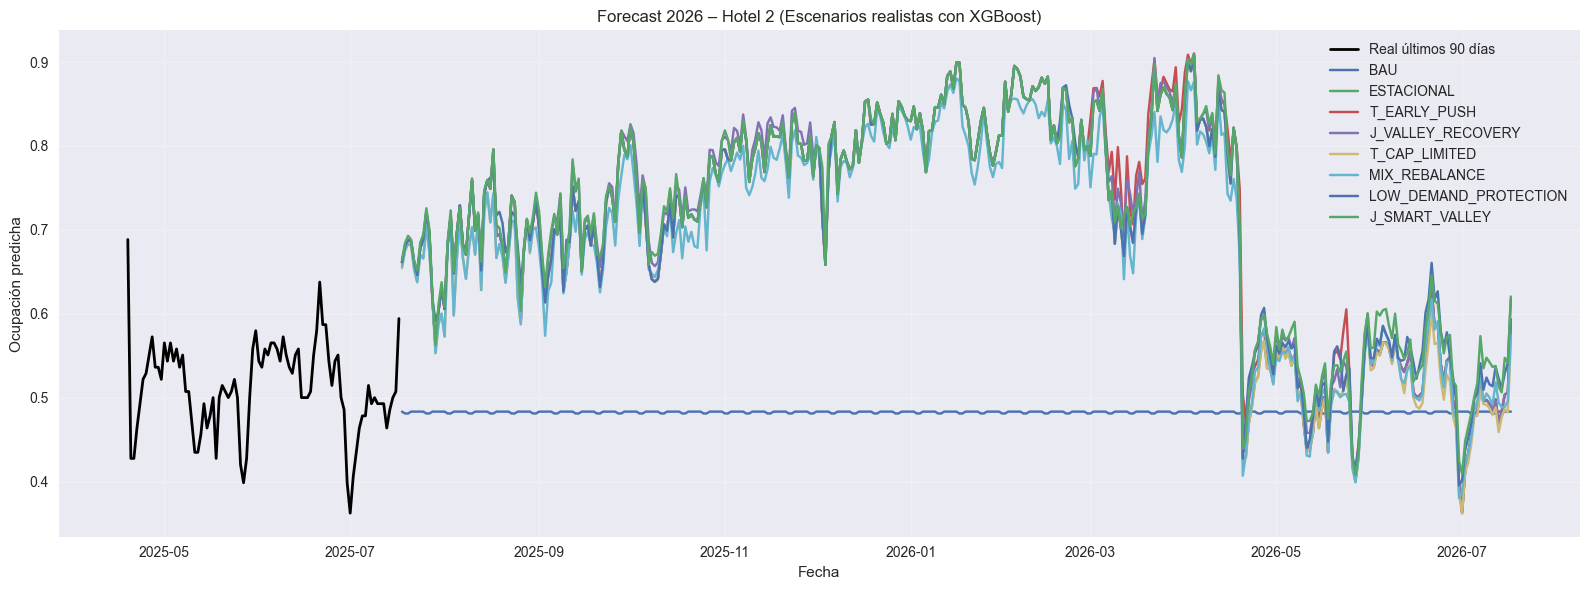

In [18]:
df_forecast["fecha"] = pd.to_datetime(df_forecast["fecha"])
df_forecast = df_forecast.set_index("fecha")

plt.figure(figsize=(16, 6))
plt.plot(
    df_train.tail(90).index,
    df_train.tail(90)[TARGET],
    color="black", lw=2, label="Real últimos 90 días"
)
for scenario in df_forecast["scenario"].unique():
    subset = df_forecast[df_forecast["scenario"] == scenario]
    plt.plot(subset.index, subset["y_pred"], label=scenario)

plt.title("Forecast 2026 – Hotel 2 (Escenarios realistas con XGBoost)")
plt.xlabel("Fecha")
plt.ylabel("Ocupación predicha")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Conclusión del Forecast Multiescenario — Hotel 2
### XGBoost + Escenarios de Revenue Management Realistas

El forecast de **Hotel 2** se construye sobre el modelo final seleccionado en la
fase de modelado: **XGBoost**, que ha demostrado un rendimiento excelente
(MAE ≈ 0.045) y una elevada capacidad para capturar la relación entre ocupación,
mix de touroperadores (`rn_*`) y estructura temporal, utilizando exclusivamente
**variables causales contemporáneas**.

El análisis confirma que Hotel 2 es un hotel **vacacional altamente estructurado**, donde:

- **T domina el volumen total y define el régimen temporal del hotel**,
- **J actúa como la principal palanca correctora en periodos de baja ocupación**,
- y el resto de canales desempeñan un papel secundario o táctico.

Todos los escenarios simulados representan **decisiones reales de Revenue Management**,
como asignación de cupos, priorización de canales o estrategias defensivas. En ningún
caso se modifica la demanda del mercado ni se introduce demanda artificial.

---

## Análisis detallado de escenarios (WHAT‑IF realistas)

### 1. BAU — *Business As Usual*

Escenario inercial sin gestión activa.
La ocupación permanece prácticamente plana, sin capturar la estacionalidad real del hotel.

Este escenario sirve como **línea base de comparación**, mostrando que sin intervención
el hotel pierde capacidad explicativa y operativa frente a su propia dinámica estacional.

---

### 2. ESTACIONAL — *Patrón histórico real*

Reproducción fiel del patrón histórico día‑mes del hotel.

El resultado muestra:
- picos elevados en temporada alta,
- valles pronunciados en primavera y otoño.

Este escenario confirma que **la estacionalidad es estructural** y establece el marco
operativo real sobre el que deben evaluarse las decisiones de Revenue Management.

---

### 3. T_EARLY_PUSH — *Adelanto de ventas con T*

Estrategia clásica de turoperación orientada a abrir cupos T antes del verano.

- Mejora ligeramente la rampa de entrada a temporada alta.
- No incrementa el nivel máximo de ocupación.

El análisis SHAP (global y temporal) confirma que **T actúa como canal estructural**,
asegurando volumen y estabilidad, pero **no como palanca de recuperación** en periodos
valle. Este escenario debe interpretarse como **aseguramiento de base**, no como
estrategia de crecimiento.

---

### 4. J_VALLEY_RECOVERY — *Recuperación de valles (calendarizada)*

Escenario focalizado que refuerza J en primavera y otoño.

- Eleva ocupación en valles.
- Reduce la amplitud estacional sin afectar los picos.

Este comportamiento está plenamente alineado con el SHAP temporal, que muestra una
influencia positiva de J precisamente en periodos de baja ocupación. Se trata de uno
de los escenarios **más sólidos y accionables** del forecast.

---

### 5. T_CAP_LIMITED — *Limitación de T en picos*

Reducción de cupos T en periodos cercanos a saturación.

- Impacto limitado sobre la ocupación.
- Permite optimizar margen y reducir dependencia.

El SHAP temporal muestra que T tiene un impacto marginal neutro en picos, por lo que
esta estrategia resulta coherente desde el punto de vista operativo y económico.

---

### 6. MIX_REBALANCE — *Redistribución general del mix*

Escenario de ajuste global del mix, reduciendo T y reforzando otros canales.

El impacto es limitado y muy similar al escenario base, lo que confirma que **los
cambios de mix generalistas no son suficientes** si no se actúa sobre la palanca
correcta en el momento adecuado.

Este escenario se mantiene como **escenario exploratorio**, útil como contraste frente
a estrategias selectivas.

---

### 7. LOW_DEMAND_PROTECTION — *Protección en baja demanda*

Estrategia defensiva que refuerza canales en días especialmente flojos.

- Mejora puntual en mínimos.
- Impacto moderado.

Es una estrategia válida como apoyo táctico, aunque menos eficiente que el refuerzo
específico de J observado en otros escenarios.

---

### 8. J_SMART_VALLEY — *Refuerzo dinámico guiado por SHAP* ⭐

Escenario avanzado que extiende el enfoque calendarizado del refuerzo de J.

El incremento de J se activa **únicamente en aquellos días futuros que coinciden con
patrones históricos de baja ocupación**, identificados a partir del comportamiento real
del hotel y coherentes con la influencia positiva observada en el SHAP temporal.

Este escenario:
- actúa solo donde el hotel muestra elasticidad real,
- evita intervenir en periodos donde J no aporta impacto,
- y conecta explícitamente la interpretabilidad temporal del modelo con el diseño
  del forecast.

Se trata del **escenario más preciso, eficaz y directamente guiado por el modelo**.

---

## Conclusión global del Forecast Hotel 2

### 1. El principal reto de Hotel 2 son los valles, no los picos
La estacionalidad condiciona toda la operación. La optimización pasa por
**recuperar periodos débiles**, no por forzar crecimientos artificiales en alta ocupación.

### 2. T define el régimen, pero no corrige valles
Asegura volumen y estabilidad estructural, pero no aporta elasticidad cuando
la ocupación cae.

### 3. J es la palanca estratégica clave
Es el único canal que:
- eleva ocupación en valles,
- suaviza la estacionalidad,
- y mejora las transiciones entre temporadas.

### 4. La elasticidad existe, pero es dirigida
El hotel responde únicamente a:
- acciones muy concretas,
- en momentos específicos,
- a través del canal adecuado.

El SHAP temporal permite **identificar con precisión esos momentos**, aportando una
capa operativa adicional al forecast.

### 5. Jerarquía final de escenarios

- **Escenario principal**: **J_SMART_VALLEY**
- Escenarios estratégicos: J_VALLEY_RECOVERY, T_CAP_LIMITED
- Escenarios secundarios: T_EARLY_PUSH, LOW_DEMAND_PROTECTION
- Escenario exploratorio: MIX_REBALANCE

Esta jerarquía diferencia claramente entre palancas reales, estrategias de soporte
y escenarios de contraste.

---

## Validación de realismo

Todos los escenarios representan **decisiones reales de un hotel vacacional**:

- asignación selectiva de cupos,
- control de dependencia en picos,
- refuerzo técnico en baja demanda.

La incorporación del **SHAP temporal** garantiza que estas decisiones no se basen
únicamente en heurísticas, sino en **el comportamiento dinámico observado por el
modelo XGBoost**.

---

### Conclusión final

El forecast multiescenario de Hotel 2 no busca maximizar artificialmente la ocupación,
sino **identificar dónde actuar, cuándo hacerlo y con qué palancas reales**.

La integración del SHAP temporal transforma el forecast en una herramienta:

- explicativa,
- accionable,
- guiada por datos,
- y alineada con Revenue Management profesional.

Hotel 2 queda así caracterizado como un hotel donde **la optimización no pasa por
crecer en picos, sino por recuperar valles con precisión**.